### Thyroid Nodule Segmentation — Project Setup

**Architecture:** DeepLabV3+ with EfficientNet-B5 backbone, augmented with hierarchical Grouped Channel Attention (GCA).
**Dataset:** TN3K (Gong et al., 2021).
**Goal of this notebook:** validate the full training pipeline end-to-end with a baseline model. The GCA modules are defined as a standalone block here; we will integrate them into the architecture in a follow-up notebook once the pipeline is verified.

---

# 1. General Settings

## 1A. Install dependencies

In [1]:
# Colab provides torch and torchvision; we install the segmentation library and Albumentations
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.4.0

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.7 MB/s eta 0:00:00


## 1B. Imports and global setup

In [43]:
import os
import random
from pathlib import Path
from typing import Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device selection
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")

Device: cuda
GPU: Tesla T4
CUDA: 12.8


## 1C. Mount Google Drive

We persist data and checkpoints on Drive so they survive Colab session restarts.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Project layout under MyDrive
PROJECT_ROOT = Path('/content/drive/MyDrive/thyroid_seg')
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'

for d in (PROJECT_ROOT, DATA_DIR, CHECKPOINTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Checkpoints:  {CHECKPOINTS_DIR}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/thyroid_seg
Data dir:     /content/drive/MyDrive/thyroid_seg/data
Checkpoints:  /content/drive/MyDrive/thyroid_seg/checkpoints


# 2. Import Data and Preprocessing

## 2A. Get the TN3K dataset

The TN3K dataset (Gong et al., 2021) is hosted on Google Drive by the original authors. Get the link from the [TRFE-Net repository README](https://github.com/haifangong/TRFE-Net-for-thyroid-nodule-segmentation).

**One-time manual step:**
1. Download the TN3K archive from the Drive link in the repo README
2. Upload the archive to `MyDrive/thyroid_seg/data/`
3. Run the cell below to extract

**Expected structure** after extraction (`DATA_DIR / 'tn3k'`):

```
tn3k/
    train/
        image/   (.jpg files)
        mask/    (.png files, binary masks)
    test/
        image/
        mask/
```

If the archive layout differs, adjust the cell below (or restructure manually before extraction).

In [4]:
TN3K_ROOT = DATA_DIR / 'tn3k'

if not TN3K_ROOT.exists():
    zip_candidates = list(DATA_DIR.glob('*.zip')) + list(DATA_DIR.glob('*.tar*'))
    if not zip_candidates:
        raise FileNotFoundError(
            f"No archive found in {DATA_DIR}. "
            f"Please download TN3K manually and upload to that folder."
        )
    archive = zip_candidates[0]
    print(f"Extracting {archive.name} ...")
    if archive.suffix == '.zip':
        !unzip -q "{archive}" -d "{DATA_DIR}"
    else:
        !tar -xf "{archive}" -C "{DATA_DIR}"
    print("Done.")

    # After extraction, the actual root is likely named after the zip file's stem.
    # Update TN3K_ROOT to reflect the actual extracted path.
    # The original description assumed a folder named 'tn3k', but the archive's name suggests 'Thyroid Dataset'.
    TN3K_ROOT = DATA_DIR / archive.stem
    print(f"Adjusted dataset root to: {TN3K_ROOT}") # Inform the user about the change
else:
    print(f"Dataset already present at {TN3K_ROOT}")

# Quick inventory
print("\nContents of dataset root:")
for item in sorted(TN3K_ROOT.iterdir()):
    print(f"  {item.name}/")
    if item.is_dir():
        for sub in sorted(item.iterdir())[:5]:
            print(f"    {sub.name}")

Extracting Thyroid Dataset.zip ...
replace /content/drive/MyDrive/thyroid_seg/data/Thyroid Dataset/DDTI dataset/DDTI.pdf? [y]es, [n]o, [A]ll, [N]one, [r]ename: n A
replace /content/drive/MyDrive/thyroid_seg/data/Thyroid Dataset/DDTI dataset/DDTI.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Done.
Adjusted dataset root to: /content/drive/MyDrive/thyroid_seg/data/Thyroid Dataset

Contents of dataset root:
  DDTI dataset/
    DDTI.pdf
    DDTI.zip
    readme.txt
  tg3k/
    tg3k-trainval.json
    thyroid-image
    thyroid-mask
  tn3k/
    test-image
    test-mask
    tn3k-trainval-fold0.json
    tn3k-trainval-fold1.json
    tn3k-trainval-fold2.json


## 2B. PyTorch Dataset class

In [5]:
class TN3KDataset(Dataset):
    """TN3K dataset with optional RAM preloading for faster training."""

    FLAT_MAP = {
        "trainval": ("trainval-image", "trainval-mask"),
        "train":    ("trainval-image", "trainval-mask"),
        "test":     ("test-image",     "test-mask"),
    }

    def __init__(self, root, split="trainval", transform=None, preload=True):
        self.root = Path(root)
        self.split = split
        self.transform = transform
        self.preload = preload

        if split in self.FLAT_MAP:
            img_folder, mask_folder = self.FLAT_MAP[split]
            flat_img  = self.root / img_folder
            flat_mask = self.root / mask_folder
            if flat_img.exists():
                self.image_dir = flat_img
                self.mask_dir  = flat_mask
            else:
                self.image_dir = self.root / split / "image"
                self.mask_dir  = self.root / split / "mask"
        else:
            self.image_dir = self.root / split / "image"
            self.mask_dir  = self.root / split / "mask"

        if not self.image_dir.exists():
            raise FileNotFoundError(f"Image dir not found: {self.image_dir}")
        if not self.mask_dir.exists():
            raise FileNotFoundError(f"Mask dir not found: {self.mask_dir}")

        valid_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
        self.image_paths = sorted(
            p for p in self.image_dir.iterdir()
            if p.suffix.lower() in valid_exts
        )
        if not self.image_paths:
            raise RuntimeError(f"No images found in {self.image_dir}")

        # Pre-load everything into RAM
        if self.preload:
            print(f"Preloading {len(self.image_paths)} images into RAM...", end=" ")
            self._images = []
            self._masks  = []
            for p in self.image_paths:
                img  = cv2.imread(str(p), cv2.IMREAD_COLOR)
                img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                mask = cv2.imread(str(self._find_mask(p)), cv2.IMREAD_GRAYSCALE)
                mask = (mask > 127).astype(np.uint8)
                self._images.append(img)
                self._masks.append(mask)
            print("done.")

    def __len__(self):
        return len(self.image_paths)

    def _find_mask(self, img_path):
        candidate = self.mask_dir / img_path.name
        if candidate.exists():
            return candidate
        matches = list(self.mask_dir.glob(f"{img_path.stem}.*"))
        if not matches:
            raise FileNotFoundError(f"No mask for {img_path.name}")
        return matches[0]

    def __getitem__(self, idx):
        if self.preload:
            image = self._images[idx].copy()
            mask  = self._masks[idx].copy()
        else:
            image = cv2.imread(str(self.image_paths[idx]), cv2.IMREAD_COLOR)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask  = cv2.imread(str(self._find_mask(self.image_paths[idx])), cv2.IMREAD_GRAYSCALE)
            mask  = (mask > 127).astype(np.uint8)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask  = transformed["mask"]

        if isinstance(mask, torch.Tensor) and mask.ndim == 2:
            mask = mask.unsqueeze(0).float()
        elif isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return {"image": image, "mask": mask, "filename": self.image_paths[idx].name}

In [6]:
class TransformedSubset(torch.utils.data.Dataset):
    """Subset wrapper that applies a transform on top of a base dataset.

    The base dataset must return raw (un-transformed) image and mask arrays.
    This wrapper is the right tool when you want to share a single in-RAM
    copy of the data across multiple subsets that need different transforms
    (e.g., train with augmentation and val without).

    Args:
        base_dataset: A TN3KDataset instance built with transform=None.
        indices:      Iterable of integer indices into the base dataset.
        transform:    Albumentations Compose to apply at __getitem__ time.
    """

    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Resolve the global index in the base dataset
        global_idx = self.indices[idx]

        # Pull raw image and mask from the base dataset.
        # We bypass the base dataset's __getitem__ because it applies its
        # own transform; we want the raw arrays to apply ours.
        if self.base_dataset.preload:
            image = self.base_dataset._images[global_idx].copy()
            mask  = self.base_dataset._masks[global_idx].copy()
        else:
            img_path = self.base_dataset.image_paths[global_idx]
            image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask  = cv2.imread(
                str(self.base_dataset._find_mask(img_path)),
                cv2.IMREAD_GRAYSCALE,
            )
            mask = (mask > 127).astype(np.uint8)

        # Apply the subset-specific transform
        transformed = self.transform(image=image, mask=mask)
        image = transformed["image"]
        mask  = transformed["mask"]

        # Ensure mask has shape (1, H, W) and float dtype
        if isinstance(mask, torch.Tensor) and mask.ndim == 2:
            mask = mask.unsqueeze(0).float()
        elif isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        filename = self.base_dataset.image_paths[global_idx].name
        return {"image": image, "mask": mask, "filename": filename}

## 2C. Augmentation pipeline

Following Prochazka et al. (2025) recipe with Albumentations: horizontal flip, shift/scale/rotate, brightness/contrast jitter.

In [7]:
IMG_SIZE = 256  # Same as Xiao 2025; can also try 352 (Kang) for higher resolution

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def get_train_transform(size: int = IMG_SIZE) -> A.Compose:
    """Training-time augmentations + normalization."""
    return A.Compose([
        A.Resize(size, size),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
          shift_limit=0.05,
          scale_limit=0.1,   # torna a 0.1 — non tocchiamo finché il baseline non gira
          rotate_limit=20,
          border_mode=cv2.BORDER_CONSTANT,
          p=0.5,
      ),
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5,
        ),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def get_eval_transform(size: int = IMG_SIZE) -> A.Compose:
    """Validation/test transform: resize + normalize, no augmentation."""
    return A.Compose([
        A.Resize(size, size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

## 2D. Build datasets + data augmentation

Quick sanity-check that the dataset and augmentation pipeline work correctly.

In [8]:
# Build datasets
TN3K_ROOT = DATA_DIR / 'Thyroid Dataset' / 'tn3k'

import shutil

LOCAL_DATA = Path('/content/tn3k_local')

if not LOCAL_DATA.exists():
    print("Copying dataset from Drive to local disk...")
    shutil.copytree(TN3K_ROOT, LOCAL_DATA)
    print("Done.")
else:
    print("Local copy already exists.")

Copying dataset from Drive to local disk...
Done.


In [9]:
# --- Build a single in-RAM base dataset (no transform) ---
# This loads all 2879 trainval images into memory exactly once.
TN3K_LOCAL = LOCAL_DATA  # already defined earlier in the notebook
base_trainval = TN3KDataset(TN3K_LOCAL, split="trainval", transform=None, preload=True)

# --- Deterministic 85/15 split using a dedicated RNG ---
# We use a separate RandomState so the split is reproducible regardless of
# any random calls happening elsewhere in the notebook.
N_TRAINVAL = len(base_trainval)
VAL_FRACTION = 0.15

split_rng = np.random.RandomState(SEED)
all_indices = np.arange(N_TRAINVAL)
split_rng.shuffle(all_indices)

n_val = int(round(N_TRAINVAL * VAL_FRACTION))
val_indices   = all_indices[:n_val]
train_indices = all_indices[n_val:]

print(f"Total trainval: {N_TRAINVAL}")
print(f"Train subset:   {len(train_indices)} ({len(train_indices)/N_TRAINVAL:.1%})")
print(f"Val subset:     {len(val_indices)} ({len(val_indices)/N_TRAINVAL:.1%})")

# --- Wrap with transform-specific subsets ---
train_ds = TransformedSubset(base_trainval, train_indices, get_train_transform())
val_ds   = TransformedSubset(base_trainval, val_indices,   get_eval_transform())

# --- Test set stays exactly as before ---
test_ds = TN3KDataset(TN3K_LOCAL, split="test", transform=get_eval_transform(), preload=True)

print(f"Train: {len(train_ds)} images (with augmentation)")
print(f"Val:   {len(val_ds)} images (no augmentation)")
print(f"Test:  {len(test_ds)} images (no augmentation)")

Preloading 2879 images into RAM... done.
Total trainval: 2879
Train subset:   2447 (85.0%)
Val subset:     432 (15.0%)
Preloading 614 images into RAM... done.
Train: 2447 images (with augmentation)
Val:   432 images (no augmentation)
Test:  614 images (no augmentation)


# 3. Models Build and Loss Functions

Models:
*   Vanilla: DeepLabV3+ + EfficientNet-B5
*   Vanilla + GCA
*   Vanilla + SE
*   Vanilla + CBAM
 ---
Loss Functions:
*   Dice-BCE
*   Boundary Loss


## 3A. Baseline model — vanilla DeepLabV3+

Built directly from `segmentation_models_pytorch`, with EfficientNet-B5 backbone pre-trained on ImageNet. No GCA yet.

In [10]:
def build_baseline_model(
    encoder_name: str = "efficientnet-b5",
    encoder_weights: str = "imagenet",
) -> nn.Module:
    """Vanilla DeepLabV3+ baseline."""
    return smp.DeepLabV3Plus(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=1,         # binary: nodule vs background
        activation=None,   # output raw logits; sigmoid applied externally
    )


# Build and inspect
model = build_baseline_model().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Forward pass on a dummy input to verify shapes
dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    dummy_output = model(dummy_input)
print(f"\nInput:  {tuple(dummy_input.shape)}")
print(f"Output: {tuple(dummy_output.shape)}  (expected: 2, 1, {IMG_SIZE}, {IMG_SIZE})")

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b5-b6417697.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b5-b6417697.pth


100%|██████████| 117M/117M [00:02<00:00, 41.6MB/s]


Total params:     29,492,417
Trainable params: 29,492,417

Input:  (2, 3, 256, 256)
Output: (2, 1, 256, 256)  (expected: 2, 1, 256, 256)


## 3B. GCA-DeepLabV3+
---
Implementation of the GCA block adapted from Kang et al. (2025).

The module splits input channels into G groups; for each group, an independent two-layer MLP (implemented efficiently as grouped 1x1 convolutions) computes channel attention weights from spatially-pooled features.

This module is defined here but **not yet integrated** into DeepLabV3+. We will plug it in at the bottleneck (G=16), skip connection (G=4), and decoder fusion (G=8) once the baseline pipeline is validated.

### 3B-A. Grouped Channel Attention (GCA) Module

In [11]:
class GroupedChannelAttention(nn.Module):
    """Grouped Channel Attention.

    Args:
        channels: number of input channels (must be divisible by groups)
        groups: number of channel groups (G)
        reduction: channel reduction ratio R in the bottleneck MLP
    """

    def __init__(self, channels: int, groups: int = 8, reduction: int = 4):
        super().__init__()
        if channels % groups != 0:
            raise ValueError(
                f"channels ({channels}) must be divisible by groups ({groups})"
            )

        # Bottleneck size must be a multiple of groups for the grouped 1x1 conv to work
        bottleneck = max(channels // reduction, groups)
        bottleneck = (bottleneck // groups) * groups

        self.groups = groups
        self.fc1 = nn.Conv2d(channels, bottleneck, kernel_size=1, groups=groups, bias=False)
        self.fc2 = nn.Conv2d(bottleneck, channels, kernel_size=1, groups=groups, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Spatial squeeze: (B, C, H, W) -> (B, C, 1, 1)
        z = F.adaptive_avg_pool2d(x, 1)
        # Per-group MLP: reduce, activate, expand, sigmoid
        z = self.relu(self.fc1(z))
        z = self.sigmoid(self.fc2(z))
        # Channel-wise re-scaling
        return x * z


# Quick sanity check
gca = GroupedChannelAttention(channels=256, groups=16, reduction=4)
dummy = torch.randn(2, 256, 16, 16)
out = gca(dummy)
n_params = sum(p.numel() for p in gca.parameters())

print(f"Input shape:  {tuple(dummy.shape)}")
print(f"Output shape: {tuple(out.shape)}")
print(f"GCA params:   {n_params:,}")

Input shape:  (2, 256, 16, 16)
Output shape: (2, 256, 16, 16)
GCA params:   2,048


### 3B-B. Build di GCA-DeepLabV3+

In [12]:
class GCA_DeepLabV3Plus(smp.DeepLabV3Plus):
    """DeepLabV3+ with GCA module."""
    def __init__(self, encoder_name, encoder_weights, in_channels, classes):
        super().__init__(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=classes,
            )
        self.gca_bottleneck = GroupedChannelAttention(channels=512, groups=16, reduction=4)
        self.gca_skip = GroupedChannelAttention(channels=40, groups=4, reduction=4)
        self.gca_decoder = GroupedChannelAttention(channels=256, groups=8, reduction=4)

    def forward(self, x):
        enc_feature = self.encoder(x)
        enc_feature[2] = self.gca_skip(enc_feature[2])
        enc_feature[5] = self.gca_bottleneck(enc_feature[5])
        dec_feature = self.decoder(*enc_feature)
        dec_feature = self.gca_decoder(dec_feature)
        output = self.segmentation_head(dec_feature)
        return output

In [13]:
def gca_build_model():
  model = GCA_DeepLabV3Plus(
      encoder_name="efficientnet-b5",
      encoder_weights="imagenet",
      in_channels=3,
      classes=1)
  return model

## 3C. SE-DeepLabV3+

In [14]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block (Hu et al., 2018).

    Recalibrates channel-wise feature responses by modelling
    interdependencies between channels. Lightweight: only two FC layers
    with a bottleneck of size channels // reduction.

    Args:
        channels:  Number of input (and output) channels.
        reduction: Bottleneck ratio. Default 16 is standard in literature.
    """

    def __init__(self, channels, reduction=16):
        super().__init__()

        # Squeeze: global average pooling collapses H×W → 1×1
        # This gives one descriptor per channel summarising its
        # global spatial response.
        self.squeeze = nn.AdaptiveAvgPool2d(1)

        # Excitation: two FC layers learn non-linear channel dependencies.
        # First FC compresses channels → channels//reduction (bottleneck).
        # Second FC expands back to channels.
        # Sigmoid produces per-channel weights in (0, 1).
        self.excitation = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # x: (B, C, H, W)
        # squeeze: (B, C, 1, 1) → flatten → (B, C)
        # excitation: (B, C) → (B, C)
        # reshape for broadcasting: (B, C, 1, 1)
        weight = self.excitation(self.squeeze(x))
        weight = weight.unsqueeze(-1).unsqueeze(-1)

        # Channel-wise rescaling: same spatial map, reweighted channels
        return x * weight


class SE_DeepLabV3Plus(nn.Module):
    """DeepLabV3+ with a single SE block at the decoder output.

    The SE block is inserted after the decoder feature fusion and before
    the classification head. This is the lightest possible insertion:
    one attention module, one point, acting on the final 256-channel
    representation before the pixel-wise decision.

    Architecture:
        EfficientNet-B5 encoder → ASPP → decoder → SE(256) → Conv1x1 → logit
    """

    def __init__(self, encoder_name="efficientnet-b5",
                 encoder_weights="imagenet", num_classes=1):
        super().__init__()

        # Base DeepLabV3+ — identical to the Vanilla baseline
        self.base = smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=num_classes,
        )

        # SE block on the 256-channel decoder output.
        # We intercept the features before the segmentation head.
        # DeepLabV3+ in smp exposes the decoder output at 256 channels
        # before the final Conv2d(256, num_classes, 1).
        self.se = SEBlock(channels=256, reduction=16)

        # Replace the original segmentation head with our own,
        # so we can insert SE between decoder and classifier.
        # The original head is a single Conv2d(256, num_classes, kernel=1).
        self.head = nn.Conv2d(256, num_classes, kernel_size=1)

        # Disable the original head to avoid double classification.
        # We extract decoder features manually in forward().
        self.base.segmentation_head = nn.Identity()

    def forward(self, x):
        # Extract multi-scale encoder features
        features = self.base.encoder(x)

        # Decode: fuse encoder features via ASPP + skip connections
        decoder_output = self.base.decoder(*features)
        # decoder_output: (B, 256, H/4, W/4) before final upsampling

        # Upsample to input resolution — this is what smp normally does
        # inside the segmentation head before the Conv1x1
        decoder_output = nn.functional.interpolate(
            decoder_output,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False,
        )

        # SE attention on the 256-channel full-resolution feature map
        decoder_output = self.se(decoder_output)

        # Classification head: 256 → 1 channel (logit)
        return self.head(decoder_output)


def build_se_model():
    """Factory function consistent with build_baseline_model() and gca_build_model()."""
    return SE_DeepLabV3Plus(
        encoder_name="efficientnet-b5",
        encoder_weights="imagenet",
        num_classes=1,
    )

In [15]:
def count_parameters(model):
    """Count trainable parameters, total and per module."""
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    se_params = sum(p.numel() for p in model.se.parameters() if p.requires_grad)
    return total, se_params

# Sanity check
se_model = build_se_model().to(DEVICE)
dummy = torch.randn(2, 3, 256, 256).to(DEVICE)

with torch.no_grad():
    out = se_model(dummy)

total_params, se_params = count_parameters(se_model)
print(f"Output shape:      {out.shape}")          # deve essere (2, 1, 256, 256)
print(f"Total parameters:  {total_params:,}")
print(f"SE block params:   {se_params:,}")        # deve essere ~8k con reduction=16
print(f"SE overhead:       {se_params/total_params*100:.3f}%")

Output shape:      torch.Size([2, 1, 256, 256])
Total parameters:  29,500,609
SE block params:   8,192
SE overhead:       0.028%


## 3D. CBAM + DeepLabV3+

In [16]:
class CBAM(nn.Module):
    """Convolutional Block Attention Module (Woo et al., ECCV 2018).

    Applies channel attention followed by spatial attention sequentially.
    Channel branch uses both average and max pooling — this is the key
    difference from SE, which uses only average pooling. The dual pooling
    captures both the mean response (what is typically active) and the
    peak response (what is maximally active) per channel.

    Spatial branch learns WHERE to focus via a 7x7 convolution on a
    two-channel map built from channel-wise avg and max of the feature map.

    Args:
        channels:        Number of input channels.
        reduction:       Bottleneck ratio for channel attention FC layers.
        spatial_kernel:  Kernel size for the spatial attention conv (7 recommended).
    """

    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()

        # --- Channel attention ---
        # Both pooling paths share the same FC layers (weight sharing).
        # This is how it's done in the original paper.
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.channel_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.channel_sigmoid = nn.Sigmoid()

        # --- Spatial attention ---
        # Input: 2-channel map (avg and max across channel dim).
        # Output: 1-channel spatial weight map.
        assert spatial_kernel % 2 == 1, "spatial_kernel must be odd"
        padding = spatial_kernel // 2
        self.spatial_conv = nn.Conv2d(
            2, 1, kernel_size=spatial_kernel, padding=padding, bias=False
        )
        self.spatial_sigmoid = nn.Sigmoid()

    def forward(self, x):
        # --- Channel attention ---
        # avg and max pools: (B, C, 1, 1) → flatten → (B, C)
        # shared FC applied to both, then element-wise sum before sigmoid
        avg_out = self.channel_fc(self.avg_pool(x))
        max_out = self.channel_fc(self.max_pool(x))
        channel_weight = self.channel_sigmoid(avg_out + max_out)
        # reshape for broadcasting: (B, C) → (B, C, 1, 1)
        channel_weight = channel_weight.unsqueeze(-1).unsqueeze(-1)
        x = x * channel_weight

        # --- Spatial attention ---
        # build 2-channel descriptor: avg and max across channel dim
        # both shapes: (B, 1, H, W)
        avg_spatial = x.mean(dim=1, keepdim=True)
        max_spatial = x.max(dim=1, keepdim=True).values
        spatial_input = torch.cat([avg_spatial, max_spatial], dim=1)  # (B, 2, H, W)
        spatial_weight = self.spatial_sigmoid(self.spatial_conv(spatial_input))  # (B, 1, H, W)
        return x * spatial_weight


class CBAM_DeepLabV3Plus(nn.Module):
    """DeepLabV3+ with a single CBAM block at the decoder output.

    Identical insertion point as SE_DeepLabV3Plus — after decoder fusion,
    before classification head — so the comparison is fair: same position,
    different attention mechanism (SE vs CBAM).

    Architecture:
        EfficientNet-B5 encoder → ASPP → decoder → CBAM(256) → Conv1x1 → logit
    """

    def __init__(self, encoder_name="efficientnet-b5",
                 encoder_weights="imagenet", num_classes=1):
        super().__init__()

        self.base = smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=num_classes,
        )

        # CBAM on the 256-channel decoder output
        self.cbam = CBAM(channels=256, reduction=16, spatial_kernel=7)

        # Classification head (replaces the original one)
        self.head = nn.Conv2d(256, num_classes, kernel_size=1)

        # Disable original head — we intercept decoder features manually
        self.base.segmentation_head = nn.Identity()

    def forward(self, x):
        features = self.base.encoder(x)
        decoder_output = self.base.decoder(*features)

        # Upsample to input resolution before applying attention
        decoder_output = nn.functional.interpolate(
            decoder_output,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False,
        )

        # CBAM: channel attention then spatial attention
        decoder_output = self.cbam(decoder_output)

        return self.head(decoder_output)


def build_cbam_model():
    """Factory function consistent with build_se_model()."""
    return CBAM_DeepLabV3Plus(
        encoder_name="efficientnet-b5",
        encoder_weights="imagenet",
        num_classes=1,
    )

In [17]:
cbam_model = build_cbam_model().to(DEVICE)
dummy = torch.randn(2, 3, 256, 256).to(DEVICE)

with torch.no_grad():
    out = cbam_model(dummy)

total_params = sum(p.numel() for p in cbam_model.parameters() if p.requires_grad)
cbam_params  = sum(p.numel() for p in cbam_model.cbam.parameters() if p.requires_grad)

print(f"Output shape:      {out.shape}")        # deve essere (2, 1, 256, 256)
print(f"Total parameters:  {total_params:,}")
print(f"CBAM parameters:   {cbam_params:,}")    # ~8k channel + ~98 spatial
print(f"CBAM overhead:     {cbam_params/total_params*100:.3f}%")

Output shape:      torch.Size([2, 1, 256, 256])
Total parameters:  29,500,707
CBAM parameters:   8,290
CBAM overhead:     0.028%


## 3.5. Loss function — Dice + BCE

Standard combination for binary medical segmentation.

In [18]:
'''DiceBCE Loss'''
class DiceBCELoss(nn.Module):
    """Combined Dice + BCE loss."""

    def __init__(self, dice_weight: float = 1.0, bce_weight: float = 1.0, smooth: float = 1e-6):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(logits, target)

        probs = torch.sigmoid(logits)
        intersection = (probs * target).sum(dim=(1, 2, 3))
        union = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1.0 - dice.mean()

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


In [19]:
class Boundary_Loss(nn.Module):
  """DiceBCE Loss + Hausdorff Distance"""
  def __init__(self, lambda_boundary: float = 0):
    super().__init__()
    self.lambda_boundary = lambda_boundary
    self.kernel_boundary = nn.Conv2d(
        in_channels = 1,
        out_channels =1,
        kernel_size=[3,3],
        stride=1,
        padding=1,
        bias=False)
    self.kernel_boundary.weight.data = torch.tensor([[0,-1,0],[-1,4,-1],[0,-1,0]]).float().view(1,1,3,3)
    self.kernel_boundary.weight.requires_grad = False

  def update_lambda (self, epoch):
    self.lambda_boundary = min(0.02*(epoch // 10), 0.1)
    print(f"Boundary loss lambda: {self.lambda_boundary}")

  def forward(self, logits: torch.Tensor, target: torch.Tensor):
    boundary = (self.kernel_boundary(target) - target).clamp(0,1)

    pred = torch.sigmoid(logits)
    pred_boundary = (self.kernel_boundary(pred) - pred).clamp(0,1)

    binary_bce = F.binary_cross_entropy(pred_boundary, boundary)

    bce_loss = F.binary_cross_entropy_with_logits(logits, target)
    intersection = (pred * target).sum(dim = (1, 2, 3))
    union = pred.sum(dim = (1, 2, 3)) + target.sum(dim = (1, 2, 3))
    smooth = 1e-6
    dice = (2.0 * intersection + smooth) / (union + smooth)
    dice_loss = 1.0 - dice.mean()

    boundary_loss = bce_loss + dice_loss + self.lambda_boundary * binary_bce
    return boundary_loss


# 4. Training setup

## 4A. Metrics

Per-image metrics, then averaged across the batch — the convention in medical segmentation.

In [21]:
@torch.no_grad()
def compute_metrics(
    logits: torch.Tensor,
    target: torch.Tensor,
    threshold: float = 0.5,
) -> Dict[str, float]:
    """Per-image Dice, IoU, accuracy, precision, recall — averaged over batch."""
    eps = 1e-7
    preds = (torch.sigmoid(logits) > threshold).float()

    tp = (preds * target).sum(dim=(1, 2, 3))
    fp = (preds * (1 - target)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * target).sum(dim=(1, 2, 3))
    tn = ((1 - preds) * (1 - target)).sum(dim=(1, 2, 3))

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    accuracy = (tp + tn) / (tp + fp + fn + tn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    mcc = (tp * tn - (fp * fn) + eps) / ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn) + eps).sqrt()

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "accuracy": accuracy.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
        "mcc": mcc.mean().item(),
    }

In [22]:
import math

def mcc_from_counts(tp: float, fp: float, fn: float, tn: float) -> float:
    """Matthews Correlation Coefficient from global pixel counts.

    Returns a value in [-1, +1]. By convention returns 0.0 when the
    denominator is zero (degenerate cases, e.g. an all-background prediction).
    """
    numerator = tp * tn - fp * fn

    # Distribute the sqrt over the four sums for numerical stability:
    # multiplying four huge counts first (order ~1e28) loses precision,
    # so we take the root of each factor and multiply the small results.
    denominator = (
        math.sqrt(tp + fp)
        * math.sqrt(tp + fn)
        * math.sqrt(tn + fp)
        * math.sqrt(tn + fn)
    )

    if denominator == 0:
        return 0.0
    return numerator / denominator

In [23]:
def compute_nodules_detected_rate(
    pred: torch.Tensor,
    target: torch.Tensor,
    q33: float,
    q67: float,
    threshold: float = 0.5,
) -> dict:
    """Compute per-nodule detection rate stratified by size and multiplicity.

    Args:
        pred:      raw logits, shape (1, H, W) or (H, W)
        target:    binary mask, shape (1, H, W) or (H, W)
        q33:       pixel area threshold between small and medium (data-driven)
        q67:       pixel area threshold between medium and large (data-driven)
        threshold: overlap fraction to consider a nodule detected (default 0.5)

    Returns:
        Dict with keys 'small', 'medium', 'large', 'single', 'multiple',
        each containing {'detected': int, 'total': int}.
    """
    # Initialize result dict — all zeros
    result = {
        "small":    {"detected": 0, "total": 0},
        "medium":   {"detected": 0, "total": 0},
        "large":    {"detected": 0, "total": 0},
        "single":   {"detected": 0, "total": 0},
        "multiple": {"detected": 0, "total": 0},
    }

    # Convert to 2D numpy arrays
    pred_array   = (torch.sigmoid(pred) > threshold).float().squeeze().cpu().numpy()
    target_array = target.squeeze().cpu().numpy().astype(np.uint8)

    labeled_mask, num_nodules = label(target_array)
    if num_nodules == 0:
        return result

    # Multiplicity group for this image — applies to ALL nodules in the image
    group = "single" if num_nodules == 1 else "multiple"

    for k in range(1, num_nodules + 1):
        nodule_mask = (labeled_mask == k)
        area        = int(nodule_mask.sum())
        overlap     = pred_array[nodule_mask].sum() / area
        detected    = int(overlap >= threshold)

        # Size bin using data-driven thresholds
        if area < q33:
            size_bin = "small"
        elif area < q67:
            size_bin = "medium"
        else:
            size_bin = "large"

        # Update size bin
        result[size_bin]["total"]    += 1
        result[size_bin]["detected"] += detected

        # Update multiplicity bin
        result[group]["total"]    += 1
        result[group]["detected"] += detected

    return result

## 4B. Training and evaluation loops

In [24]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    metrics_acc = {"dice": 0.0, "iou": 0.0}
    n_batches = 0

    pbar = tqdm(loader, desc="  train", leave=False, ncols=80)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        masks  = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss   = loss_fn(logits, masks) # DiceBCe e Boundary I versione
        # loss = loss_fn(logits, masks, images) # Boundary Adattiva
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        m = compute_metrics(logits, masks)
        for k in metrics_acc:
            metrics_acc[k] += m[k]
        n_batches += 1

        pbar.set_postfix(loss=f"{loss.item():.4f}", dice=f"{m['dice']:.4f}")

    return {
        "loss": total_loss / n_batches,
        **{k: v / n_batches for k, v in metrics_acc.items()},
    }


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    metrics_acc = {k: 0.0 for k in ["dice", "iou", "accuracy", "precision", "recall"]}
    n_batches = 0

    total_detected = 0
    total_nodules = 0

    pbar = tqdm(loader, desc="  eval ", leave=False, ncols=80)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        masks  = batch["mask"].to(device, non_blocking=True)

        logits = model(images)
        loss   = loss_fn(logits, masks) # DiceBCe e Boundary I versione
        # loss = loss_fn(logits, masks, images) # Boundary Adattiva
        total_loss += loss.item()

        m = compute_metrics(logits, masks)
        for k in metrics_acc:
            metrics_acc[k] += m[k]
        n_batches += 1

        pbar.set_postfix(loss=f"{loss.item():.4f}", dice=f"{m['dice']:.4f}")

    return {
        "loss": total_loss / n_batches,
        **{k: v / n_batches for k, v in metrics_acc.items()},
    }

## 4C. Data Loader

In [25]:
# Hyperparameters
BATCH_SIZE = 4       # fits B5 at 256x256 on Colab T4/A100; lower if OOM
NUM_EPOCHS = 100       # SANITY CHECK; raise to 50-100 for full run
LR = 1e-4
NUM_WORKERS = 2      # Set to 0 to avoid BatchNorm issues with num_workers > 0
# WARMUP_LOSS_STEPS = 10 # Set 0 to use only BoundaryLoss, set = NUM_EPOCHS to use DiceBCE_loss

# DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# 5. Training run

In [ ]:
# Model, loss, optimizer, scheduler
# model = build_baseline_model().to(DEVICE)     # VANILLA
# model = gca_build_model().to(DEVICE)          # GCA
# model = build_se_model().to(DEVICE)           # SE
model = build_cbam_model().to(DEVICE)         # CBAM

# loss_fn = DiceBCELoss()                  # loss DiceBCE
loss_fn = Boundary_Loss().to(DEVICE)     # loss Boundary

print(f"{type(loss_fn).__name__}_" + f"{type(model).__name__}")

Boundary_Loss_CBAM_DeepLabV3Plus


In [ ]:
# Training loop
best_dice = 0.0
PATIENCE = 30  # stop if val Dice doesn't improve for 30 epochs
epochs_no_improve = 0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Starting epoch {epoch}...", flush=True)
    loss_fn.update_lambda(epoch) # per DiceBCE e Adaptive
    train_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    val_metrics   = evaluate(model, val_loader, loss_fn, DEVICE)  # was test_loader
    scheduler.step()

    history.append({
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}":   v for k, v in val_metrics.items()},     # was test_
    })

    print(
        f"Epoch {epoch:03d} | "
        f"train: loss {train_metrics['loss']:.4f}, dice {train_metrics['dice']:.4f} | "
        f"val:   loss {val_metrics['loss']:.4f}, dice {val_metrics['dice']:.4f}, "
        f"iou {val_metrics['iou']:.4f}"
    )

    # Save best checkpoint based on VAL dice
    if val_metrics['dice'] > best_dice:
        best_dice = val_metrics['dice']
        epochs_no_improve = 0
        endpoint = "best_" + f"{type(loss_fn).__name__}_" + f"{type(model).__name__}" + ".pt"
        ckpt_path = CHECKPOINTS_DIR / endpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_dice': best_dice,
            'config': {
                'encoder': 'efficientnet-b5',
                'img_size': IMG_SIZE,
                'batch_size': BATCH_SIZE,
                'lr': LR,
            },
        }, ckpt_path)
        print(f"  -> saved checkpoint to {ckpt_path.name}")
    else:
      epochs_no_improve += 1
      if epochs_no_improve >= PATIENCE:
          print(f"  -> early stopping at epoch {epoch}")
          break

print(f"\nBest val Dice (in {NUM_EPOCHS} epochs): {best_dice:.4f}")

Starting epoch 1...
Boundary loss lambda: 0.0


Epoch 001 | train: loss 0.7776, dice 0.6044 | val:   loss 0.4503, dice 0.7470, iou 0.6331
  -> saved checkpoint to best_Boundary_Loss_CBAM_DeepLabV3Plus.pt
Starting epoch 2...
Boundary loss lambda: 0.0


Epoch 002 | train: loss 0.4367, dice 0.7564 | val:   loss 0.3706, dice 0.7875, iou 0.6790
  -> saved checkpoint to best_Boundary_Loss_CBAM_DeepLabV3Plus.pt
Starting epoch 3...
Boundary loss lambda: 0.0


Epoch 003 | train: loss 0.3642, dice 0.7948 | val:   loss 0.3528, dice 0.7960, iou 0.6915
  -> saved checkpoint to best_Boundary_Loss_CBAM_DeepLabV3Plus.pt
Starting epoch 4...
Boundary loss lambda: 0.0


Epoch 004 | train: loss 0.3217, dice 0.8165 | val:   loss 0.3466, dice 0.8000, iou 0.6957
  -> saved checkpoint to best_Boundary_Loss_CBAM_DeepLabV3Plus.pt
Starting epoch 5...
Boundary loss lambda: 0.0


...

Epoch 076 | train: loss 0.0996, dice 0.9494 | val:   loss 0.3996, dice 0.8275, iou 0.7353
Starting epoch 77...


Boundary loss lambda: 0.1


Epoch 077 | train: loss 0.1006, dice 0.9491 | val:   loss 0.3968, dice 0.8276, iou 0.7356
Starting epoch 78...


Boundary loss lambda: 0.1


Epoch 078 | train: loss 0.0985, dice 0.9501 | val:   loss 0.3971, dice 0.8266, iou 0.7345
  -> early stopping at epoch 78

Best val Dice (in 100 epochs): 0.8294


# 6. Conformal Prediction

## 6A. Pre-processing e data distribution

Counting pixel number for each nodule

In [26]:
from scipy.ndimage import label

def nodule_pixel_count(mask):
    """Args:
        mask: binary mask, either a torch.Tensor of shape (1, H, W) / (H, W)
              or a numpy array of shape (H, W). Values in {0, 1}.

    Returns:
        Sorted list (descending) of native Python ints, one per connected
        component. Empty list if the mask has no foreground pixel."""
    if isinstance(mask, torch.Tensor):
      mask_2d = mask.detach().squeeze().cpu().numpy().astype(np.uint8)
    else:
      mask_2d = mask.squeeze().astype(np.uint8)

    labeled, n_nodules = label(mask_2d)
    if n_nodules == 0:
      return []

    count_pixels_nodules = [int((labeled == k).sum()) for k in range(1, n_nodules +1)]
    count_pixels_nodules.sort(reverse = True)

    return count_pixels_nodules

Metadata for the test set, in order to make a balanced calibration-test split

In [27]:
def build_dataset_metadata(dataset):
    """Compute per-image metadata over a segmentation dataset.

    Args:
        dataset: a PyTorch Dataset where each sample is a dict with keys
                 'image', 'mask', 'filename'.

    Returns:
        List of dicts, one per sample, each containing:
        'index', 'filename', 'nodule_pixels', 'n_nodules',
        'total_pixels', 'main_size'.
    """
    metadata = []

    for idx in range(len(dataset)):
      sample = dataset[idx]
      counts = nodule_pixel_count(sample["mask"])
      metadata.append({
          "index": idx,
          "filename": sample["filename"],
          "nodule_pixels": counts,
          "n_nodules": len(counts),
          "total_pixels": sum(counts),
          "main_size": counts[0] if counts else 0
          })

    return metadata

In [28]:
test_metadata = build_dataset_metadata(test_ds)

Check the test set distribution

In [29]:
from collections import Counter

print("=== n_nodules distribution ===")
print(Counter(e["n_nodules"] for e in test_metadata))

sizes = [e["main_size"] for e in test_metadata if e["main_size"] > 0]
q33, q67 = np.percentile(sizes, 33), np.percentile(sizes, 67)
print(f"\n=== main_size quantiles: q33={q33:.0f}px  q67={q67:.0f}px ===")

def size_bin(ms):
    if ms == 0:     return "empty"
    if ms < q33:    return "small"
    if ms < q67:    return "medium"
    return "large"

print(Counter(size_bin(e["main_size"]) for e in test_metadata))

=== n_nodules distribution ===
Counter({1: 544, 2: 65, 3: 4, 4: 1})

=== main_size quantiles: q33=2255px  q67=8063px ===
Counter({'medium': 208, 'small': 203, 'large': 203})


To build the stratified (on nodules size and count) calibration set for conformal prediction

In [30]:
def stratified_calibration_split(
    metadata: list,
    calibration_split: float = 0.3,
    # quantiles: tuple = (0.33, 0.67),  # only if the split is by main_size, now it is by single-multiple stratification
    seed: int = 42
    ):
    """Split metadata indices into (calibration, test_final) stratified by main_size.

    Bin thresholds are computed as quantiles of the non-empty main_size
    distribution, making them data-driven rather than arbitrary constants.

    Args:
        metadata:     output of build_dataset_metadata.
        cal_fraction: fraction of each bin assigned to calibration (default 0.30).
        quantiles:    (q_low, q_high) for bin boundaries, in (0, 1) (default 0.33, 0.67).
        seed:         random seed for reproducibility.

    Returns:
        (calib_indices, test_indices): two sorted lists of ints.
        (q_low_val, q_high_val): the actual pixel thresholds computed from data.
    """
    rng = np.random.default_rng(seed)
    groups = {"single": [],
              "multiple": []}

    for idx in range(len(metadata)):
        sample = metadata[idx]
        if sample["n_nodules"] == 1:
            groups["single"].append(idx)
        else:
            groups["multiple"].append(idx)

    singles = np.array(groups["single"])
    multiples = np.array(groups["multiple"])

    rng.shuffle(singles)
    rng.shuffle(multiples)

    n_calibr_single = round(0.3 * len(singles))
    n_calibr_multiple = round(0.3 * len(multiples))

    cal_idx = np.concatenate([singles[:n_calibr_single], multiples[:n_calibr_multiple]])
    test_idx = np.concatenate([singles[n_calibr_single:], multiples[n_calibr_multiple:]])

    return (sorted(cal_idx), sorted(test_idx))

Check for the size stratification after the single-multiple split

In [31]:
cal_idx, test_idx = stratified_calibration_split(test_metadata)
cal_meta = [test_metadata[i] for i in cal_idx]
test_meta = [test_metadata[i] for i in test_idx]

print("=== n_nodules distribution ===")
print(Counter(e["n_nodules"] for e in test_metadata))

sizes = [e["main_size"] for e in test_metadata if e["main_size"] > 0]
q33, q67 = np.percentile(sizes, 33), np.percentile(sizes, 67)
print(f"\n=== main_size quantiles: q33={q33:.0f}px  q67={q67:.0f}px ===")

def size_bin(ms):
    if ms == 0:     return "empty"
    if ms < q33:    return "small"
    if ms < q67:    return "medium"
    return "large"

print("Calibration Split", Counter(size_bin(e["main_size"]) for e in cal_meta))
print("Test Split", Counter(size_bin(e["main_size"]) for e in test_meta))

=== n_nodules distribution ===
Counter({1: 544, 2: 65, 3: 4, 4: 1})

=== main_size quantiles: q33=2255px  q67=8063px ===
Calibration Split Counter({'large': 65, 'medium': 64, 'small': 55})
Test Split Counter({'small': 148, 'medium': 144, 'large': 138})


## 6B. Conformal prediction wrapper

In [32]:
import math

class Conformal_Prediction_Wrapper:
    """Post-hoc split conformal prediction wrapper for binary segmentation.

    Wraps a trained, frozen segmentation model and produces calibrated
    pixel-level prediction sets with marginal coverage guarantee >= 1 - alpha.

    Conformity score: s_i = 1 - p_hat[y_i]  (per-pixel, pooled across images).

    Usage:
        wrapper = ConformalSegmentationWrapper(model, device, alpha=0.1)
        wrapper.calibrate(calib_loader)
        out = wrapper.predict_set(image_tensor)
        metrics = wrapper.evaluate(test_loader)
    """
    def __init__(self,
                 model: nn.Module,
                 device: torch.device,
                 alpha = 0.1):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.alpha = alpha
        self.q_hat = None

    @torch.no_grad()
    def _forward_probs(self,
                      images: torch.Tensor):
        """Run model forward pass and return sigmoid probabilities.

        Args:
            images: tensor of shape (B, 3, H, W), already on self.device.

        Returns:
            Probability maps of shape (B, 1, H, W), values in [0, 1].
        """
        logits = self.model(images)
        probs = torch.sigmoid(logits)
        return probs

    @torch.no_grad()
    def calibrate(self,
                  calib_loader: DataLoader):
        """Compute non-conformity scores on calibration set and store q_hat.

        Args:
            calib_loader: DataLoader over the calibration split.
                          Each batch is a dict with 'image' and 'mask'.

        Returns:
            q_hat (float): the fitted quantile threshold, also stored as self.q_hat.
        """
        all_scores = []
        for batch in calib_loader:
            images = batch["image"].to(self.device)
            masks = batch["mask"]
            probs = self._forward_probs(images).cpu()
            scores = torch.where(masks == 1, 1 - probs, probs)
            all_scores.append(scores.flatten())

        all_scores = torch.cat(all_scores).numpy()
        n = len(all_scores)
        # quantile with finite correction
        level = math.ceil((n + 1)*(1 - self.alpha))/n
        q_hat = np.quantile(all_scores, min(level, 1.0))
        self.q_hat = float(q_hat)
        print(f"Calibration done | n_pixels={n:,} | q_hat={self.q_hat:.4f} | alpha={self.alpha}")

        return q_hat

    @torch.no_grad()
    def predict_set(self,
                    image: torch.Tensor):
        if self.q_hat is None:
            raise RuntimeError("The class is not calibrated. Call calibrate() first")

        if image.dim() == 3:
            image = image.unsqueeze(0)

        image = image.to(self.device)
        probs = self._forward_probs(image).cpu()
        lower = (probs > 1 - self.q_hat).float()
        upper = (probs > self.q_hat).float()
        uncertain = upper - lower

        out = {"probs": probs,
                "upper": upper,
                "lower": lower,
                "uncertain": uncertain
        }
        return out

    @torch.no_grad()
    def evaluate(self,
                 test_loader: DataLoader,
                 metadata: list) -> dict:
        """Evaluate calibrated wrapper on held-out test set.

        Args:
            test_loader: DataLoader over the final test split.
            metadata:    output of build_dataset_metadata, used to
                         retrieve n_nodules per image via filename lookup.

        Returns:
            Nested dict with keys 'overall', 'single', 'multiple',
            each containing empirical_coverage, uncertain_fraction,
            upper_dice, lower_dice.
        """
        if self.q_hat is None:
            raise RuntimeError("Wrapper not calibrated. Call calibrate() first.")

        # --- Lookup table: filename → n_nodules ---
        # O(1) access inside the loop instead of scanning metadata every time
        fn_to_nnodules = {e["filename"]: e["n_nodules"] for e in metadata}

        # --- Accumulators ---
        # For each group we track pixel-level counts needed for all metrics.
        # 'covered'       : pixels where GT label is inside its prediction set
        # 'uncertain'     : pixels in upper but not in lower (the uncertainty band)
        # 'total_pixels'  : total pixels seen (denominator for coverage/uncertain)
        # 'upper_tp/fp/fn': for Dice of the upper mask vs GT
        # 'lower_tp/fp/fn': for Dice of the lower mask vs GT
        def empty_acc():
            return {
                "covered": 0, "uncertain": 0, "total_pixels": 0,
                "upper_tp": 0, "upper_fp": 0, "upper_fn": 0,
                "lower_tp": 0, "lower_fp": 0, "lower_fn": 0,
                "n_images": 0,
            }

        accs = {
            "overall":  empty_acc(),
            "single":   empty_acc(),
            "multiple": empty_acc(),
        }

        # --- Main loop ---
        for batch in test_loader:
            images    = batch["image"]
            masks     = batch["mask"]       # (B, 1, H, W), CPU, values {0, 1}
            filenames = batch["filename"]   # list of str, length B

            # predict_set handles device movement internally
            out = self.predict_set(images)
            upper     = out["upper"]        # (B, 1, H, W), CPU
            lower     = out["lower"]
            uncertain = out["uncertain"]

            B = images.shape[0]
            for i in range(B):
                m   = masks[i]      # (1, H, W)
                u   = upper[i]
                lo  = lower[i]
                unc = uncertain[i]
                fn  = filenames[i]

                # Coverage: a foreground pixel is covered if it is in upper (u==1);
                # a background pixel is covered if it is NOT in lower (lo==0).
                covered = (((m == 1) & (u == 1)).sum() +
                           ((m == 0) & (lo == 0)).sum()).item()

                total_px  = m.numel()
                uncert_px = unc.sum().item()

                # Dice accumulators for upper mask
                u_tp = (u * m).sum().item()
                u_fp = (u * (1 - m)).sum().item()
                u_fn = ((1 - u) * m).sum().item()

                # Dice accumulators for lower mask
                l_tp = (lo * m).sum().item()
                l_fp = (lo * (1 - m)).sum().item()
                l_fn = ((1 - lo) * m).sum().item()

                # Determine group from filename lookup
                n_nod = fn_to_nnodules.get(fn, 1)
                group = "single" if n_nod == 1 else "multiple"

                # Update both overall and the specific group
                for key in ("overall", group):
                    a = accs[key]
                    a["covered"]      += covered
                    a["uncertain"]    += uncert_px
                    a["total_pixels"] += total_px
                    a["upper_tp"]     += u_tp
                    a["upper_fp"]     += u_fp
                    a["upper_fn"]     += u_fn
                    a["lower_tp"]     += l_tp
                    a["lower_fp"]     += l_fp
                    a["lower_fn"]     += l_fn
                    a["n_images"]     += 1

        # --- Compute final metrics from accumulators ---
        def metrics_from_acc(a: dict) -> dict:
            eps = 1e-7
            return {
                # Coverage: fraction of GT pixels inside their prediction set
                # Target: >= 1 - alpha = 0.90
                "empirical_coverage":  round(a["covered"]   / (a["total_pixels"] + eps), 4),

                # Uncertain fraction: how tight is the wrapper?
                # Lower = better (tighter prediction sets)
                "uncertain_fraction":  round(a["uncertain"] / (a["total_pixels"] + eps), 4),

                # Dice of outer mask (upper bound on segmentation quality)
                "upper_dice": round(
                    (2 * a["upper_tp"] + eps) /
                    (2 * a["upper_tp"] + a["upper_fp"] + a["upper_fn"] + eps), 4),

                # Dice of inner mask (lower bound — conservative foreground only)
                "lower_dice": round(
                    (2 * a["lower_tp"] + eps) /
                    (2 * a["lower_tp"] + a["lower_fp"] + a["lower_fn"] + eps), 4),

                "n_images": a["n_images"],
            }

        results = {k: metrics_from_acc(v) for k, v in accs.items()}

        # --- Pretty print ---
        print(f"\n{'='*60}")
        print(f"Conformal Prediction Evaluation  |  alpha={self.alpha}  |  q_hat={self.q_hat:.4f}")
        print(f"{'='*60}")
        header = f"{'group':<10} {'n_img':>6} {'coverage':>10} {'uncertain':>10} {'upper_dice':>11} {'lower_dice':>11}"
        print(header)
        print("-" * 60)
        for group in ("overall", "single", "multiple"):
            r = results[group]
            print(f"{group:<10} {r['n_images']:>6} "
                  f"{r['empirical_coverage']:>10.4f} "
                  f"{r['uncertain_fraction']:>10.4f} "
                  f"{r['upper_dice']:>11.4f} "
                  f"{r['lower_dice']:>11.4f}")
        print(f"{'='*60}\n")

        return results

In [33]:
def visualize_conformal(wrapper, loader, n_samples=4, seed=42):
    """Visualize conformal prediction sets as overlay on original image.

    Two columns per row:
        - Left:  image + GT nodule (red)
        - Right: image + certain prediction lower mask (blue) + uncertainty band (green)

    Args:
        wrapper:   calibrated Conformal_Prediction_Wrapper
        loader:    DataLoader over the final test split
        n_samples: number of images to show
        seed:      for reproducible sample selection
    """
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

    batch     = next(iter(loader))
    images    = batch["image"]
    masks     = batch["mask"]
    filenames = batch["filename"]

    rng     = np.random.default_rng(seed)
    indices = rng.choice(images.shape[0],
                         size=min(n_samples, images.shape[0]),
                         replace=False)

    out = wrapper.predict_set(images)

    fig, axes = plt.subplots(len(indices), 2,
                             figsize=(10, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["GT nodule (red)", "Certain nodule (blue)  +  Uncertain border (green)"]

    for row, idx in enumerate(indices):

        # De-normalize image
        img_np = images[idx].permute(1, 2, 0).cpu().numpy()
        img_np = img_np * IMAGENET_STD + IMAGENET_MEAN
        img_np = np.clip(img_np, 0, 1)

        gt        = masks[idx].squeeze().cpu().numpy()
        lower     = out["lower"][idx].squeeze().cpu().numpy()
        uncertain = out["uncertain"][idx].squeeze().cpu().numpy()

        # Red overlay — GT nodule
        red = np.zeros((*gt.shape, 4))
        red[gt == 1] = [1.0, 0.1, 0.1, 0.15]

        # Blue overlay — certain prediction (lower mask)
        blue = np.zeros((*lower.shape, 4))
        blue[lower == 1] = [0.1, 0.3, 1.0, 0.15]

        # Green overlay — uncertainty band (border)
        green = np.zeros((*uncertain.shape, 4))
        green[uncertain == 1] = [0.1, 0.9, 0.1, 0.15]

        # Left: image + GT in red
        axes[row, 0].imshow(img_np)
        axes[row, 0].imshow(red)

        # Right: image + certain prediction in blue + border in green
        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(blue)
        axes[row, 1].imshow(green)

        if row == 0:
            for ax, title in zip(axes[row], col_titles):
                ax.set_title(title, fontsize=10, fontweight="bold")

        axes[row, 0].set_ylabel(filenames[idx], fontsize=7,
                                rotation=0, labelpad=80, va="center")

        for ax in axes[row]:
            ax.axis("off")

    plt.suptitle(
        f"Conformal Prediction  |  α={wrapper.alpha}  |  q̂={wrapper.q_hat:.4f}",
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()

## 6C. Conformal Prediction Output

In [34]:
from torch.utils.data import Subset

# 1. Build metadata and split
test_metadata          = build_dataset_metadata(test_ds)
cal_idx, test_idx      = stratified_calibration_split(test_metadata, seed=SEED)

# 2. Build subsets and loaders
calib_ds    = Subset(test_ds, cal_idx)
final_ds    = Subset(test_ds, test_idx)
calib_loader = DataLoader(calib_ds, batch_size=16, shuffle=False, num_workers=0)
final_loader = DataLoader(final_ds, batch_size=16, shuffle=False, num_workers=0)

# 3. Instantiate wrapper on the best model
model  = build_cbam_model().to(DEVICE)
wrapper = Conformal_Prediction_Wrapper(model, DEVICE, alpha=0.05)

# 4. Load checkpoint
ckpt = torch.load(CHECKPOINTS_DIR / "best_DiceBCELoss_CBAM_DeepLabV3Plus.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])

# 5. Calibrate and evaluate
wrapper.calibrate(calib_loader)
results = wrapper.evaluate(final_loader, test_metadata)

Calibration done | n_pixels=12,058,624 | q_hat=0.0142 | alpha=0.05

Conformal Prediction Evaluation  |  alpha=0.05  |  q_hat=0.0142
group       n_img   coverage  uncertain  upper_dice  lower_dice
------------------------------------------------------------
overall       430     0.9874     0.0353      0.8712      0.8731
single        381     0.9888     0.0353      0.8803      0.8817
multiple       49     0.9768     0.0351      0.7813      0.7842



Calibration done | n_pixels=12,058,624 | q_hat=0.0142 | alpha=0.05


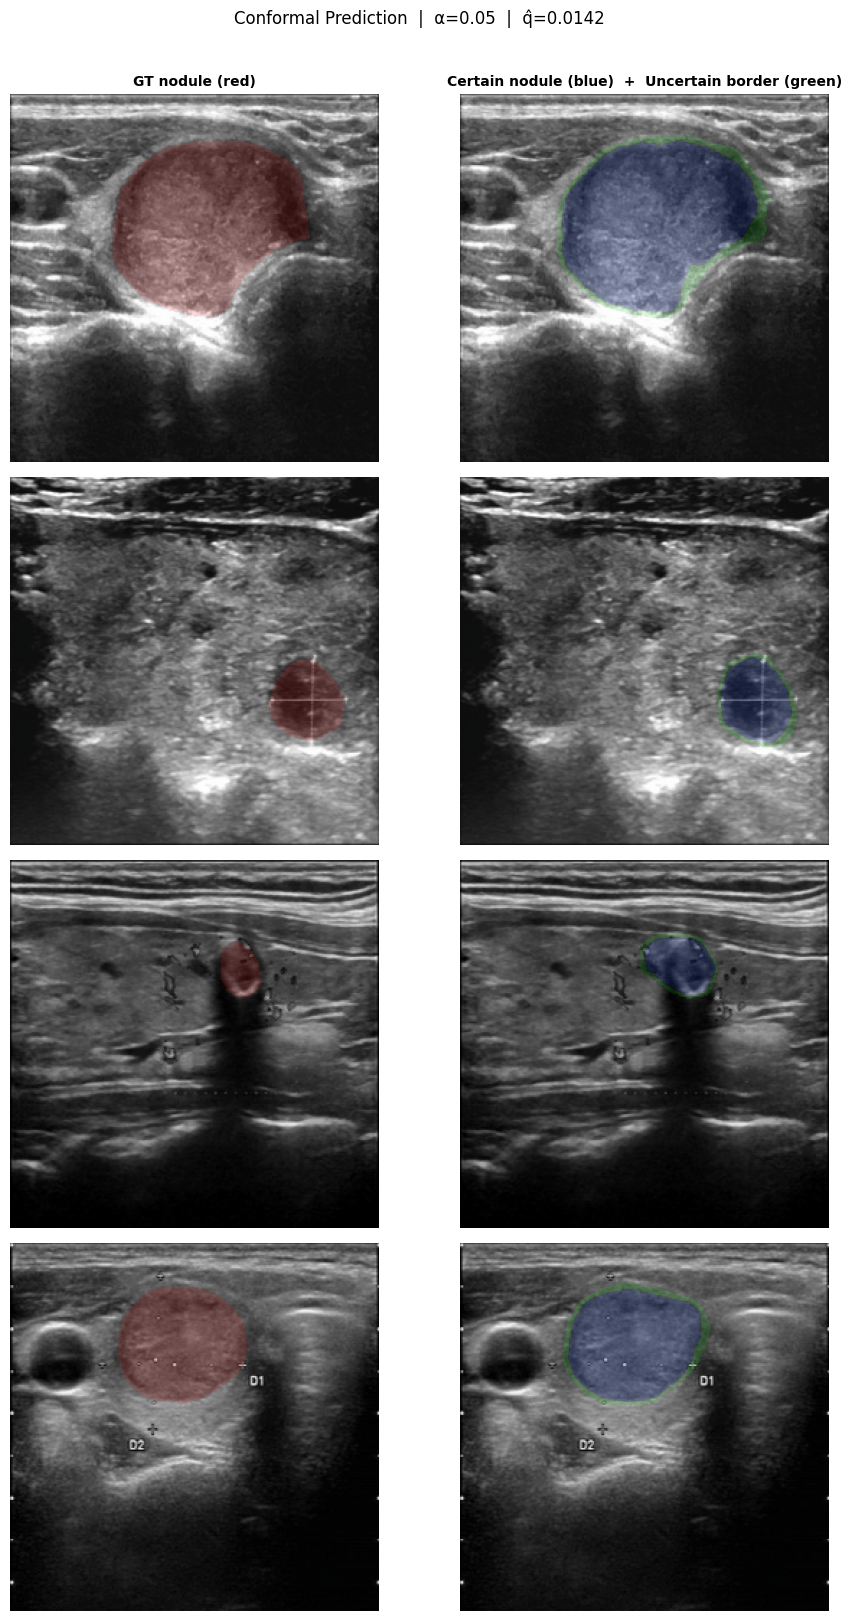

In [35]:
# Re-instantiate wrapper with alpha=0.05
wrapper = Conformal_Prediction_Wrapper(
    build_cbam_model().to(DEVICE), DEVICE, alpha=0.05
)
ckpt = torch.load(
    CHECKPOINTS_DIR / "best_DiceBCELoss_CBAM_DeepLabV3Plus.pt",
    map_location=DEVICE
)
wrapper.model.load_state_dict(ckpt["model_state_dict"])
wrapper.calibrate(calib_loader)

# Visualize
visualize_conformal(wrapper, final_loader, n_samples=4, seed=62)

# 7. Model Diagnostic

### 7A. Visualize Model Predictions (Inference Check)
Let's check if the model is producing any sensible masks on the test set. This helps determine if the issue is a simple thresholding problem, a coordinate flip, or total failure to generalize.

In [36]:
''' Model type '''
# model = gca_build_model().to(DEVICE)          # GCA
model = build_baseline_model().to(DEVICE)     # VANILLA
# model = build_se_model().to(DEVICE)           # SE
# model = build_cbam_model().to(DEVICE)         # CBAM

'''Loss functions'''
loss_fn = DiceBCELoss()                  # loss DiceBCE
# loss_fn = Boundary_Loss().to(DEVICE)     # loss Boundary

Loaded best weights for visualization: /content/drive/MyDrive/thyroid_seg/checkpoints/best_DiceBCELoss_DeepLabV3Plus.pt


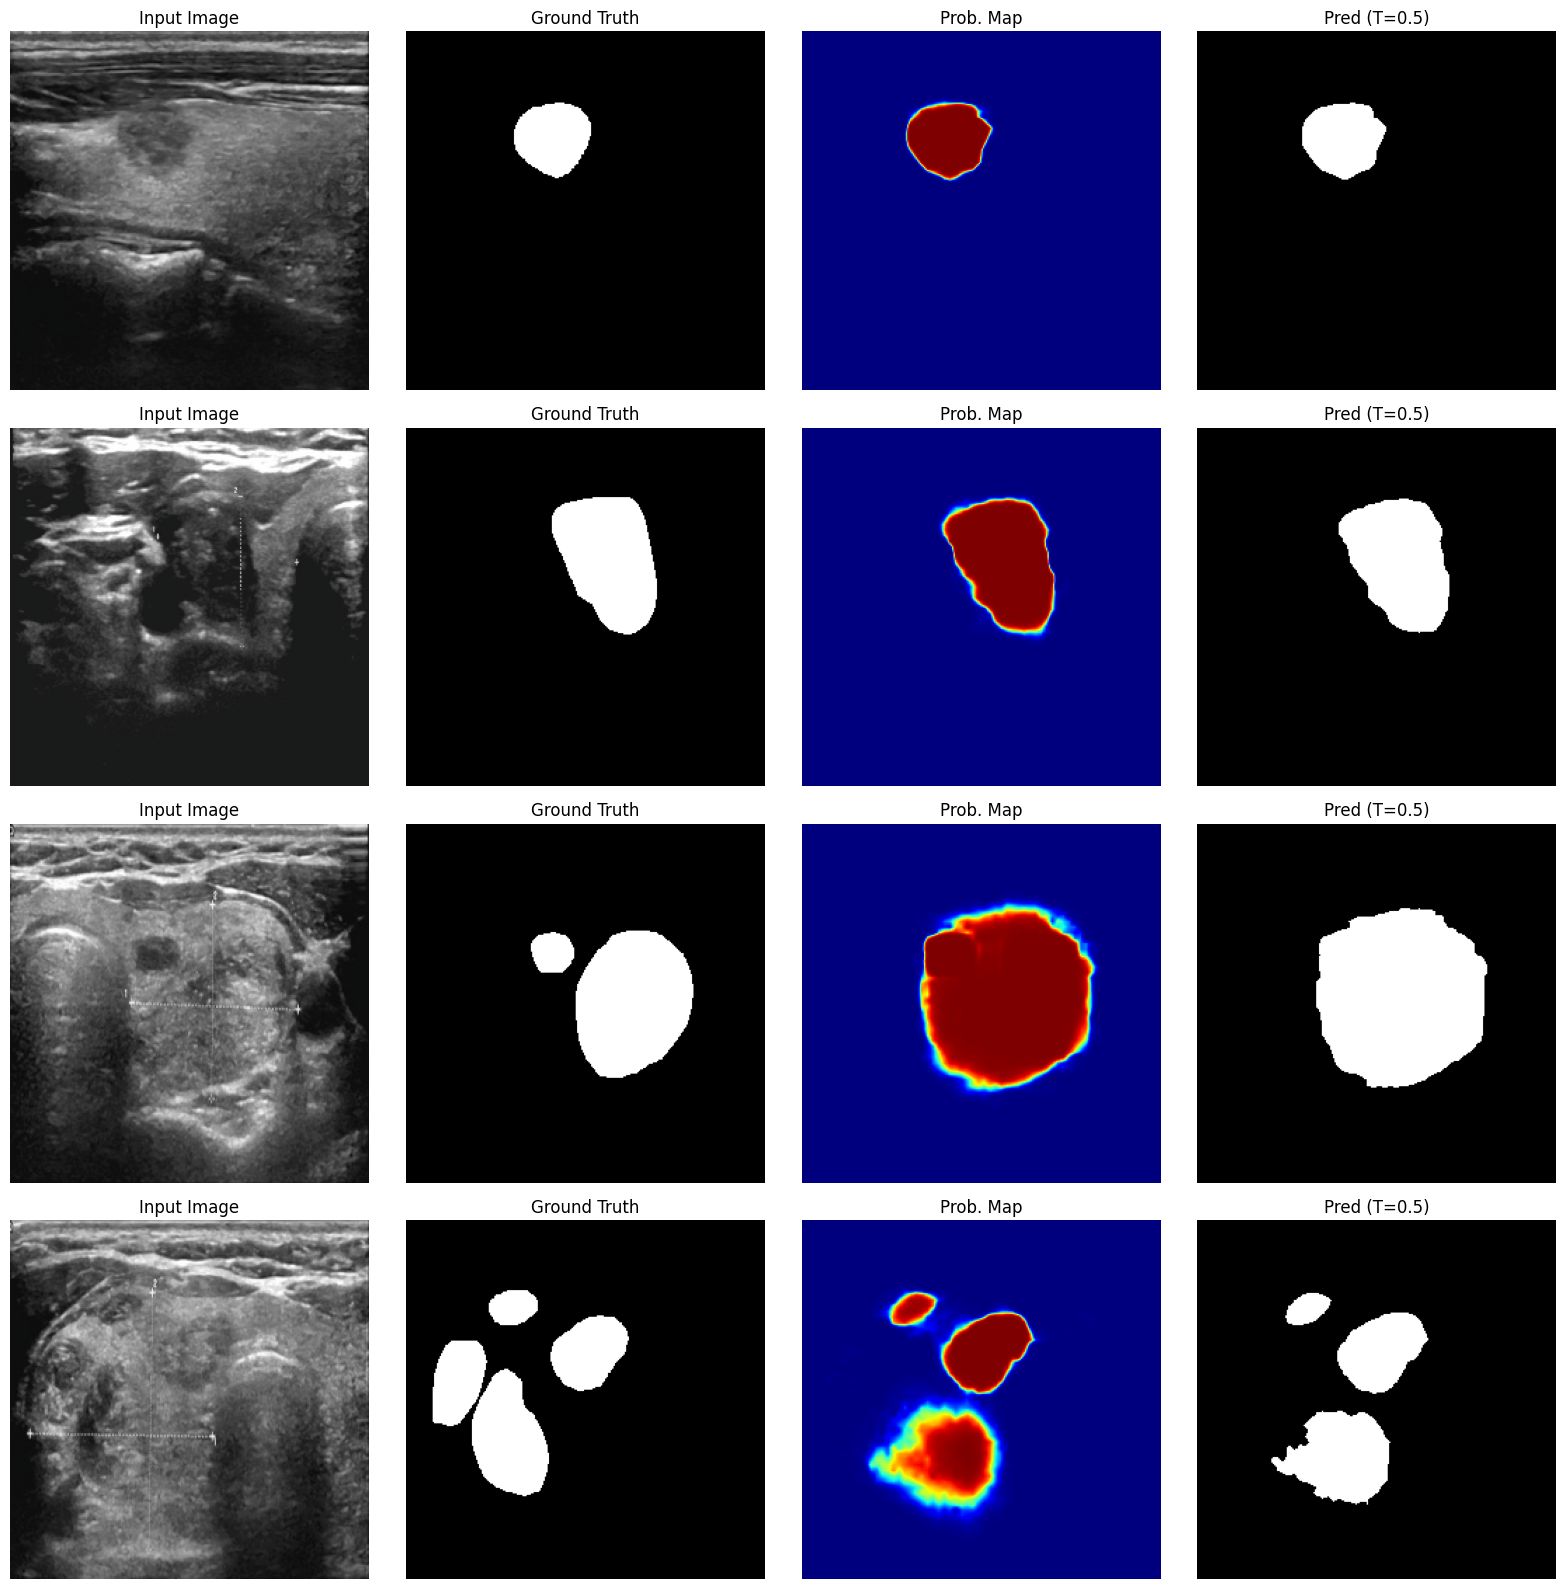

In [37]:
def visualize_predictions(model, loader, device, n_samples=4, threshold=0.5):
    model.eval()
    samples_shown = 0
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))

    with torch.no_grad():
        for batch in loader:
            if samples_shown >= n_samples: break

            images = batch["image"].to(device)
            masks = batch["mask"].to(device)
            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            for i in range(images.size(0)):
                if samples_shown >= n_samples: break

                # Denormalize image
                img_np = images[i].cpu().permute(1, 2, 0).numpy()
                img_np = img_np * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
                img_np = np.clip(img_np, 0, 1)

                gt_np = masks[i].cpu().squeeze().numpy()
                prob_np = probs[i].cpu().squeeze().numpy()
                pred_np = preds[i].cpu().squeeze().numpy()

                axes[samples_shown, 0].imshow(img_np)
                axes[samples_shown, 0].set_title("Input Image")
                axes[samples_shown, 1].imshow(gt_np, cmap='gray')
                axes[samples_shown, 1].set_title("Ground Truth")
                axes[samples_shown, 2].imshow(prob_np, cmap='jet')
                axes[samples_shown, 2].set_title("Prob. Map")
                axes[samples_shown, 3].imshow(pred_np, cmap='gray')
                axes[samples_shown, 3].set_title(f"Pred (T={threshold})")

                for ax in axes[samples_shown]: ax.axis('off')
                samples_shown += 1

    plt.tight_layout()
    plt.show()

# Load best weights before visualizing
endpoint = "best_" + f"{type(loss_fn).__name__}_" + f"{type(model).__name__}" + ".pt"
ckpt_path = CHECKPOINTS_DIR / endpoint

if ckpt_path.exists():
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best weights for visualization: {ckpt_path}")
else:
    print(f"Checkpoint not found: {ckpt_path}")

visualize_predictions(model, test_loader, DEVICE)

### 7B. Evaluation checkpoints

In [47]:
def evaluation_checkpoint_full(model, test_loader, device, threshold: float = 0.5,
                                q33: float | None = None, q67: float | None = None):
    """Unified evaluation: computes both global (pooled) and per-image metrics
    in a single pass over the test set.

    Returns a dict with:
      - global_metrics: dataset-level scores (Dice_g, MCC_g, DR stratified)
      - per_image_df: DataFrame with one row per image (Dice, MCC, gt_area_px)
      - summary: aggregated statistics of per-image values (mean/median/std/P10)

    The two views are complementary:
      * global_metrics use pooled TP/FP/FN/TN over the whole test set (micro).
      * per_image_df keeps one score per image, so we can then compute mean,
        median, std and worst-10% (macro-style, but exposed as a distribution).
    """
    model.eval()
    eps = 1e-7

    # --- Global accumulators (pooled confusion-matrix counts) ---
    tp_total = fp_total = fn_total = tn_total = 0.0

    # --- Per-image storage: one record per test image ---
    per_image_records = []

    # --- Detection-rate accumulators, stratified by size and count ---
    # Structure: {bin_name: {"detected": int, "total": int}}
    dr_acc = {
        "small":    {"detected": 0, "total": 0},
        "medium":   {"detected": 0, "total": 0},
        "large":    {"detected": 0, "total": 0},
        "single":   {"detected": 0, "total": 0},
        "multiple": {"detected": 0, "total": 0},
    }

    # If size thresholds are not provided, we could compute them from the test set here,
    # but we assume they are passed in (as done in your current pipeline).
    assert q33 is not None and q67 is not None, "Pass q33 and q67 explicitly."

    with torch.no_grad():
        # Note: we iterate the DataLoader (batches) for efficiency, but inside
        # each batch we loop over single images to collect per-image metrics.
        for batch in test_loader:
            images    = batch["image"].to(device)
            masks     = batch["mask"].to(device)          # (B, 1, H, W)
            filenames = batch["filename"]                 # list of length B

            logits = model(images)
            preds  = (torch.sigmoid(logits) > threshold).float()

            # --- Global counts: accumulated over the whole batch at once ---
            tp_total += (preds * masks).sum().item()
            fp_total += (preds * (1 - masks)).sum().item()
            fn_total += ((1 - preds) * masks).sum().item()
            tn_total += ((1 - preds) * (1 - masks)).sum().item()

            # --- Per-image loop: metrics + detection rate in the same pass ---
            batch_size = images.shape[0]
            for i in range(batch_size):
                p = preds[i]
                m = masks[i]

                # Per-image confusion counts
                tp_i = (p * m).sum().item()
                fp_i = (p * (1 - m)).sum().item()
                fn_i = ((1 - p) * m).sum().item()
                tn_i = ((1 - p) * (1 - m)).sum().item()

                # Per-image Dice and MCC
                dice_i = (2 * tp_i + eps) / (2 * tp_i + fp_i + fn_i + eps)
                mcc_i  = mcc_from_counts(tp_i, fp_i, fn_i, tn_i)

                per_image_records.append({
                    "filename":   filenames[i],
                    "dice":       dice_i,
                    "mcc":        mcc_i,
                    "gt_area_px": m.sum().item(),
                })

                # Detection rate: reuses your existing function
                result = compute_nodules_detected_rate(
                    logits[i], masks[i], q33=q33, q67=q67
                )
                for bin_name in dr_acc:
                    dr_acc[bin_name]["detected"] += result[bin_name]["detected"]
                    dr_acc[bin_name]["total"]    += result[bin_name]["total"]

    # ---------------------------------------------------------------
    # --- Dataset-level (global / micro) metrics
    # ---------------------------------------------------------------
    dice_global = (2 * tp_total + eps) / (2 * tp_total + fp_total + fn_total + eps)
    iou_global  = (tp_total + eps) / (tp_total + fp_total + fn_total + eps)
    prec_global = (tp_total + eps) / (tp_total + fp_total + eps)
    rec_global  = (tp_total + eps) / (tp_total + fn_total + eps)
    mcc_global  = mcc_from_counts(tp_total, fp_total, fn_total, tn_total)

    global_metrics = {
        "dice_global": round(dice_global * 100, 2),
        "iou_global":  round(iou_global  * 100, 2),
        "prec_global": round(prec_global * 100, 2),
        "rec_global":  round(rec_global  * 100, 2),
        "mcc_global":  round(mcc_global, 3),
        "DR_small":    round(dr_acc["small"]["detected"]    / max(dr_acc["small"]["total"], 1), 3),
        "DR_medium":   round(dr_acc["medium"]["detected"]   / max(dr_acc["medium"]["total"], 1), 3),
        "DR_large":    round(dr_acc["large"]["detected"]    / max(dr_acc["large"]["total"], 1), 3),
        "DR_single":   round(dr_acc["single"]["detected"]   / max(dr_acc["single"]["total"], 1), 3),
        "DR_multiple": round(dr_acc["multiple"]["detected"] / max(dr_acc["multiple"]["total"], 1), 3),
        "n_images":    len(per_image_records),
    }

    # ---------------------------------------------------------------
    # --- Per-image DataFrame + summary statistics (macro view)
    # ---------------------------------------------------------------
    per_image_df = pd.DataFrame(per_image_records)

    summary = {
        # Dice per-image aggregations
        "mDice":     round(per_image_df["dice"].mean()   * 100, 2),
        "mDice_50":  round(per_image_df["dice"].median() * 100, 2),
        "mDice_10":  round(per_image_df["dice"].quantile(0.10) * 100, 2),
        # MCC per-image aggregations (kept in native [-1,1] scale)
        "mMCC":      round(per_image_df["mcc"].mean(),   3),
        "mMCC_50":   round(per_image_df["mcc"].median(), 3),
        "mMCC_10":   round(per_image_df["mcc"].quantile(0.10), 3),
    }
    return {
        "global_metrics": global_metrics,
        "summary":        summary,
        "per_image_df":   per_image_df,
    }

In [49]:
models_to_evaluate = [
    (build_baseline_model(), CHECKPOINTS_DIR / "best_DiceBCELoss_DeepLabV3Plus.pt",       "Vanilla + DiceBCE"),
    (build_baseline_model(), CHECKPOINTS_DIR / "best_Boundary_Loss_DeepLabV3Plus.pt",     "Vanilla + Boundary"),
    (gca_build_model(),      CHECKPOINTS_DIR / "best_DiceBCELoss_GCA_DeepLabV3Plus.pt",   "GCA + DiceBCE"),
    (gca_build_model(),      CHECKPOINTS_DIR / "best_Boundary_Loss_GCA_DeepLabV3Plus.pt", "GCA + Boundary"),
    (build_se_model(),       CHECKPOINTS_DIR / "best_DiceBCELoss_SE_DeepLabV3Plus.pt",    "SE + DiceBCE"),
    (build_se_model(),       CHECKPOINTS_DIR / "best_Boundary_Loss_SE_DeepLabV3Plus.pt",  "SE + Boundary"),
    (build_cbam_model(),     CHECKPOINTS_DIR / "best_DiceBCELoss_CBAM_DeepLabV3Plus.pt",  "CBAM + DiceBCE"),
    (build_cbam_model(),     CHECKPOINTS_DIR / "best_Boundary_Loss_CBAM_DeepLabV3Plus.pt","CBAM + Boundary"),
]

# Collect all results here so we can also build a summary table at the end.
all_results = {}

for model, ckpt, name in models_to_evaluate:
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")

    # Load checkpoint before evaluation
    checkpoint = torch.load(ckpt, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)

    # Full evaluation in one pass
    out = evaluation_checkpoint_full(
        model, test_loader, DEVICE,
        q33=q33, q67=q67, # q33 and q67 comes from the section 6A
    )
    all_results[name] = out

    g = out["global_metrics"]
    s = out["summary"]

    # ---- Segmentation metrics (Tab. 1 of the paper) ----
    print(f"\n  [Segmentation metrics — global]")
    print(f"    Dice_g = {g['dice_global']:>6.2f}   IoU_g = {g['iou_global']:>6.2f}   "
          f"MCC_g = {g['mcc_global']:>6.3f}")
    print(f"    Prec_g = {g['prec_global']:>6.2f}   Rec_g = {g['rec_global']:>6.2f}")

    print(f"\n  [Segmentation metrics — per-image distribution]")
    print(f"    {'':>6} {'mean':>8} {'median':>8} {'P10':>8}")
    print(f"    {'Dice':>6} {s['mDice']:>8.2f} {s['mDice_50']:>8.2f} "
          f"{s['mDice_10']:>8.2f}")
    print(f"    {'MCC':>6} {s['mMCC']:>8.3f} {s['mMCC_50']:>8.3f} "
          f"{s['mMCC_10']:>8.3f}")

    # ---- Detection rates (Tab. 2 of the paper) ----
    print(f"\n  [Detection rate]")
    print(f"    by size:  DR_s = {g['DR_small']:.3f}   "
          f"DR_m = {g['DR_medium']:.3f}   DR_l = {g['DR_large']:.3f}")
    print(f"    by count: DR_1 = {g['DR_single']:.3f}   DR_M = {g['DR_multiple']:.3f}")
    print(f"    (n_images = {g['n_images']})")


  Vanilla + DiceBCE

  [Segmentation metrics — global]
    Dice_g =  88.76   IoU_g =  79.79   MCC_g =  0.872
    Prec_g =  88.79   Rec_g =  88.72

  [Segmentation metrics — per-image distribution]
               mean   median      P10
      Dice    83.43    89.70    63.83
       MCC    0.829    0.886    0.628

  [Detection rate]
    by size:  DR_s = 0.861   DR_m = 0.919   DR_l = 0.970
    by count: DR_1 = 0.961   DR_M = 0.726
    (n_images = 614)

  Vanilla + Boundary

  [Segmentation metrics — global]
    Dice_g =  89.46   IoU_g =  80.92   MCC_g =  0.880
    Prec_g =  89.81   Rec_g =  89.10

  [Segmentation metrics — per-image distribution]
               mean   median      P10
      Dice    84.72    91.19    65.80
       MCC    0.843    0.900    0.656

  [Detection rate]
    by size:  DR_s = 0.891   DR_m = 0.946   DR_l = 0.980
    by count: DR_1 = 0.971   DR_M = 0.801
    (n_images = 614)

  GCA + DiceBCE

  [Segmentation metrics — global]
    Dice_g =  89.50   IoU_g =  80.99   MCC_